[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/gsipes2/gsipes2.github.io/blob/main/notebooks/IntroductionImageProcessing.ipynb)



# Introduction to Image Processing
Welcome! This notebook is designed for beginners with no prior experience in image processing. You'll learn how images are represented in code and get hands-on with common image transforms, filters, and detection techniques using Python.

## Why this matters
Image processing is everywhere: improving medical images, cleaning up photos, extracting measurements, and powering computer vision systems such as object detectors and trackers. This notebook focuses on the practical building blocks you can reuse across projects.

## What you'll learn
- How images are represented (pixels, channels, color spaces)
- Basic transforms: resizing, rotating, and cropping
- Filters: blur, sharpen, edge detection, and morphological ops
- How to inspect image statistics using histograms
- How to detect objects and faces using modern libraries
- Practical tips for tuning parameters and debugging outputs

## Requirements

To run this notebook, you need the following:

- **Python 3.8+**
- **Jupyter Notebook** (or JupyterLab)

## Tips before you start
- Run cells sequentially so variables (like `img`) are available.
- Use the provided `test_image.jpg` or change the filename to your own image.

## Resources
- OpenCV documentation: https://docs.opencv.org/

### Environment Setup
This cell sets up the environment for image and video processing. It downloads and imports essential libraries:

- `os` for file operations.
- `cv2` (OpenCV) for image and video processing.
- `numpy` for numerical operations.
- `matplotlib.pyplot` for plotting images and results.

It also defines file paths for the test image and prints a quick check to confirm that the files exists and that OpenCV is installed. This ensures all required resources are available before running further image processing tasks.

In [69]:
# Install required packages
%pip install opencv-python matplotlib numpy ipython

import cv2
import numpy as np
import matplotlib.pyplot as plt
import requests

# Direct download links for Box files
IMG_URL = 'https://uofi.box.com/shared/static/4vwmy8d4zutugdq54xj0jm98y2dsv8t0.jpg'

def download_file(url, save_path):
    r = requests.get(url, stream=True)
    r.raise_for_status()
    with open(save_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    return save_path

# Download files to /content/
img_path = '/content/test_image.jpg'

download_file(IMG_URL, img_path)

# Load image
img = cv2.imread(img_path)
print('Image loaded:', img is not None)

Note: you may need to restart the kernel to use updated packages.
Image loaded: True


## How are images represented in code?
Images are represented as multi-dimensional arrays (matrices) where each element corresponds to a pixel's color value. Gray-scale images have a single channel representing intensity. In color images, each pixel typically has three channels (Red, Green, Blue - RGB) or (Blue, Green, Red - BGR) depending on the library used. For now, let's focus on grayscale images for simplicity.

### Image Bit Depth
Images can have different bit depths, which determine the range of values each pixel can take. Common bit depths include: 8-bit (0-255), 16-bit (0-65535), and 32-bit floating point (0.0-1.0). These values come from how the numbers are stored in binary format, i.e., 8 bits can represent $2^8 = 256$ different values. The bit depth affects the image's color precision and file size. 8-bit images are most common for everyday use.

Run the cell below to see an example of an 8-bit image array that produces a smiley face.

Text(0.5, 1.0, '8-Bit Grayscale Example')

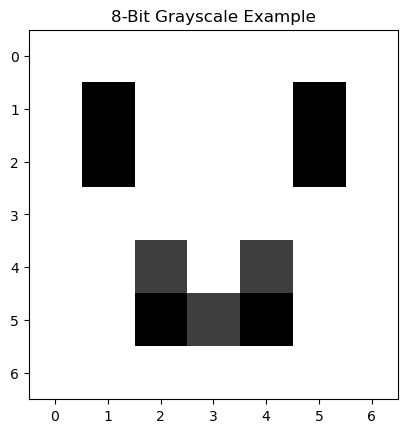

In [33]:
smiley = np.array([
    [255, 255, 255, 255, 255, 255, 255],
    [255,  50, 255, 255, 255,  50, 255],
    [255,  50, 255, 255, 255,  50, 255],
    [255, 255, 255, 255, 255, 255, 255],
    [255, 255, 100, 255, 100, 255, 255],
    [255, 255,  50, 100,  50, 255, 255],
    [255, 255, 255, 255, 255, 255, 255]])

plt.imshow(smiley, cmap='gray')
plt.title('8-Bit Grayscale Example')

## Loading and Displaying Images with OpenCV

OpenCV is a powerful library for image processing in Python. To get started,load an image and display it. Here’s how:

### Loading an Image

Use `cv2.imread()` to load an image from a file. The image is read as a NumPy array in BGR (Blue, Green, Red) format.

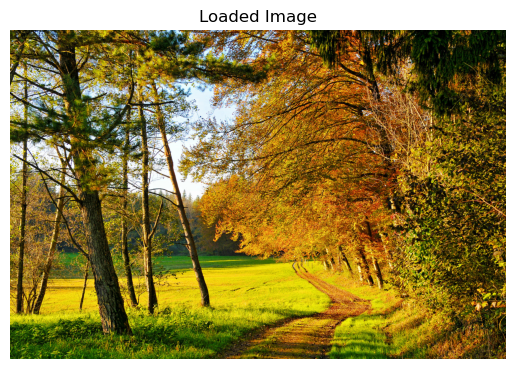

In [ ]:
# Display an image using Matplotlib
if img is not None:
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # By default, OpenCV loads images with the BGR (blue, green, red) colorspace. This line converts from the BGR colorspace to the RGB colorspace (red, green, blue)
    plt.imshow(img_rgb)
    plt.title('Loaded Image')
    plt.axis('off')
    plt.show()
else:
    print('Image not found. Try changing the filename to an image file.')

### Image Resizing and Rotation

Resizing and rotating images are essential preprocessing steps in image analysis and computer vision.

**Why resize?**  
- Reduces memory and computation time, especially for large images or real-time applications.
- Enables faster experimentation and model training.
- Helps standardize input sizes for neural networks and algorithms.

**Why rotate?**  
- Corrects image orientation for consistent analysis.
- Useful for aligning features or objects in medical, satellite, or document images.

**Tip:**  
When enlarging images, use interpolation methods (e.g., bilinear, bicubic) to avoid pixelation and preserve quality. For shrinking, simple nearest-neighbor or area interpolation is often sufficient.

Resizing and rotating are quick ways to optimize your workflow and improve downstream results.

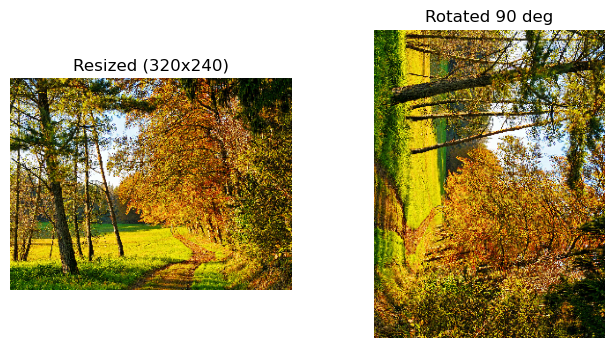

In [ ]:
# Resize and rotate examples
if img is not None:
    small = cv2.resize(img_rgb, (320, 240))
    rotated = cv2.rotate(small, cv2.ROTATE_90_CLOCKWISE)
    plt.figure(figsize=(8, 4))
    plt.subplot(1, 2, 1)
    plt.imshow(small)
    plt.title('Resized (320x240)')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(rotated)
    plt.title('Rotated 90 deg')
    plt.axis('off')
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Color Spaces and Channels

Images are made up of pixels, and each pixel can have one or more **channels** depending on the color space used. Understanding color spaces and channels is essential for effective image analysis and processing.

### What is a Color Space?
A **color space** is a specific way of representing colors numerically. It defines how pixel values map to actual colors. Common color spaces include RGB, LAB, and HSV.

### What is a Channel?
A **channel** is a single component of a color space. For example, in RGB, each pixel has three channels: Red, Green, and Blue. In grayscale images, there is only one channel representing intensity.

### Common Color Spaces

- **RGB (Red, Green, Blue) or BGR (Blue, Green, Red):**
    - Each pixel has three channels: R, G, and B.
    - Used for display and general image processing.
    - Not perceptually uniform.

- **HSV (Hue, Saturation, Value):**
    - Three channels: H (hue), S (saturation), V (value/brightness).
    - Separates color information (hue) from intensity (value).
    - Useful for color-based segmentation and filtering.

- **LAB (L\*a\*b\*):**
    - Three channels: L (lightness), a (green–red), b (blue–yellow).
    - Designed for perceptual uniformity.
    - Useful for color correction and measuring color differences.

### Why This Matters:

- **Channel manipulation:** You can process each channel separately (e.g., enhance brightness, isolate colors).
- **Visualization:** Viewing individual channels helps understand image structure and color distribution.
- **Analysis:** Some algorithms work better on specific channels (e.g., edge detection on intensity, segmentation on hue).

**Tip:**  
Choose the color space and channels that best fit your task. For example, use LAB for brightness/contrast adjustment, HSV for color segmentation, and RGB for visualization.


Run the cell below to see how an image looks in different color spaces and their individual channels.

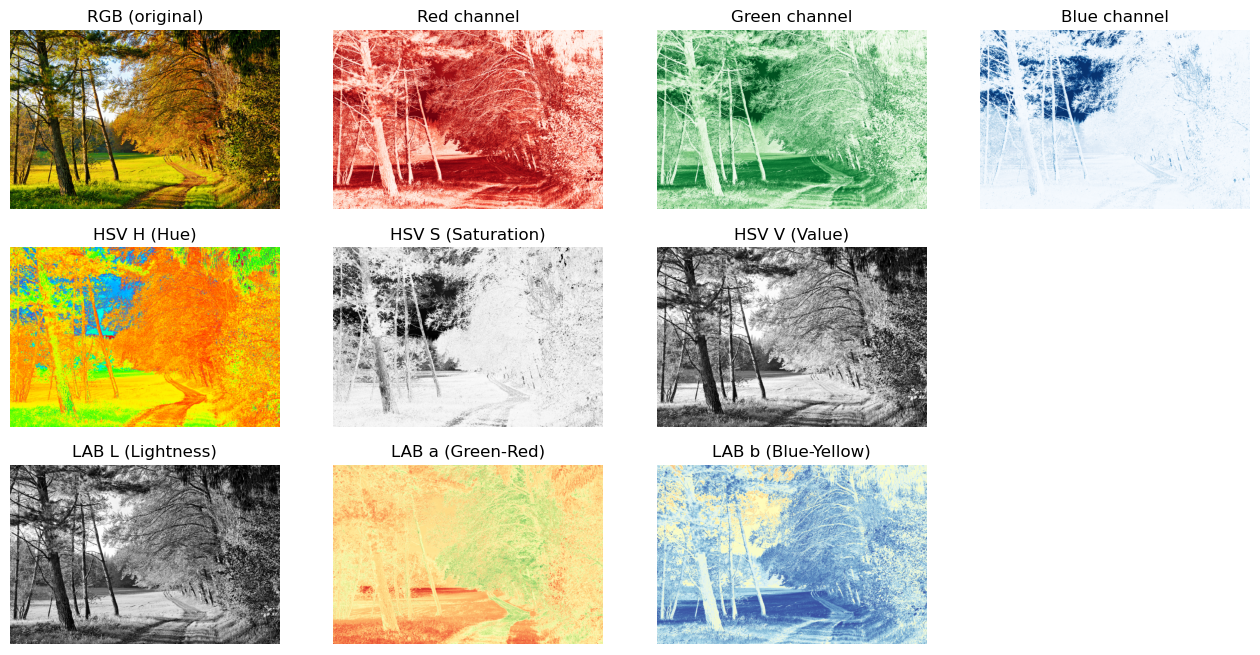

In [ ]:
# Show original image and individual color channels (RGB, LAB, HSV)
if img is not None:
    # RGB channels
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    r, g, b = img_rgb[:, :, 0], img_rgb[:, :, 1], img_rgb[:, :, 2]
    # LAB channels
    lab = cv2.cvtColor(img, cv2.COLOR_BGR2LAB)
    l_lab, a_lab, b_lab = cv2.split(lab)
    # HSV channels
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    h_hsv, s_hsv, v_hsv = cv2.split(hsv)

    plt.figure(figsize=(16, 8))
    # Row 1: RGB
    plt.subplot(3, 4, 1)
    plt.imshow(img_rgb)
    plt.title('RGB (original)')
    plt.axis('off')
    plt.subplot(3, 4, 2)
    plt.imshow(r, cmap='Reds')
    plt.title('Red channel')
    plt.axis('off')
    plt.subplot(3, 4, 3)
    plt.imshow(g, cmap='Greens')
    plt.title('Green channel')
    plt.axis('off')
    plt.subplot(3, 4, 4)
    plt.imshow(b, cmap='Blues')
    plt.title('Blue channel')
    plt.axis('off')

    # Row 3: HSV
    plt.subplot(3, 4, 5)
    plt.imshow(h_hsv, cmap='hsv')
    plt.title('HSV H (Hue)')
    plt.axis('off')
    plt.subplot(3, 4, 6)
    plt.imshow(s_hsv, cmap='gray')
    plt.title('HSV S (Saturation)')
    plt.axis('off')
    plt.subplot(3, 4, 7)
    plt.imshow(v_hsv, cmap='gray')
    plt.title('HSV V (Value)')
    plt.axis('off')
    plt.subplot(3, 4, 8)
    plt.axis('off')  # Empty for layout

    # Row 3: LAB
    plt.subplot(3, 4, 9)
    plt.imshow(l_lab, cmap='gray')
    plt.title('LAB L (Lightness)')
    plt.axis('off')
    plt.subplot(3, 4, 10)
    plt.imshow(a_lab, cmap='RdYlGn')
    plt.title('LAB a (Green-Red)')
    plt.axis('off')
    plt.subplot(3, 4, 11)
    plt.imshow(b_lab, cmap='RdYlBu')
    plt.title('LAB b (Blue-Yellow)')
    plt.axis('off')
    plt.subplot(3, 4, 12)
    plt.axis('off')  # Empty for layout

else:
    print('Image not loaded. Run the first cell.')

### Grayscale imagery

Grayscale images use a single intensity channel, making them faster to process and easier for many algorithms (e.g., edge detection, thresholding). Converting to grayscale is a common first step in image analysis.

#### Background

Most digital images are captured in color, with each pixel containing multiple values (channels) for red, green, and blue. However, many image processing tasks—such as measuring brightness, detecting edges, or segmenting objects—work best on simpler data. Grayscale images reduce complexity by representing each pixel with a single value for intensity, ranging from black (0) to white (255).

Grayscale conversion is widely used in medical imaging, document analysis, and computer vision because it:
- Removes color distractions, focusing on structure and contrast.
- Speeds up processing and reduces memory usage.
- Simplifies algorithms that rely on intensity rather than color.

**Tip:**  
Start with grayscale for tasks like thresholding, edge detection, and morphological operations. Use color only when necessary for segmentation or visualization.

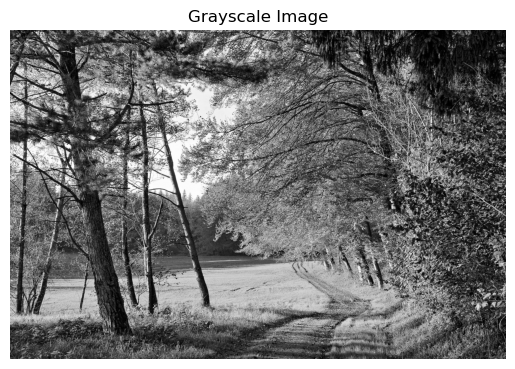

In [ ]:
# Convert the loaded image to grayscale and display it
if img is not None:
    gray = cv2.cvtColor(img_rgb, cv2.COLOR_RGB2GRAY) # Convert the image from RGB colorspace to grayscale
    plt.imshow(gray, cmap='gray')
    plt.title('Grayscale Image')
    plt.axis('off')
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Image Histograms — Background & Intuition

An **image histogram** is a graphical representation of the distribution of pixel intensities (brightness or color values) in an image. It helps you understand the overall exposure, contrast, and color balance at a glance.

### What does a histogram show?
- **X-axis:** Pixel intensity values (0–255 for 8-bit images).
- **Y-axis:** Number of pixels at each intensity.
- **Grayscale images:** One histogram for brightness.
- **Color images:** Separate histograms for each channel (Red, Green, Blue).

### Why are histograms useful?
- **Contrast:** A wide histogram means high contrast; a narrow one means low contrast.
- **Brightness:** If the histogram is shifted left, the image is dark; shifted right, it's bright.
- **Exposure:** Peaks at the ends may indicate underexposure (too dark) or overexposure (too bright).
- **Color balance:** Comparing channel histograms reveals color casts or imbalances.

### Practical uses
- **Image enhancement:** Adjust brightness/contrast or apply histogram equalization.
- **Thresholding:** Choose thresholds for binarization based on histogram shape.
- **Quality control:** Detect poor lighting or exposure problems.

Histograms are a simple but powerful tool for diagnosing and improving images in any image processing workflow.

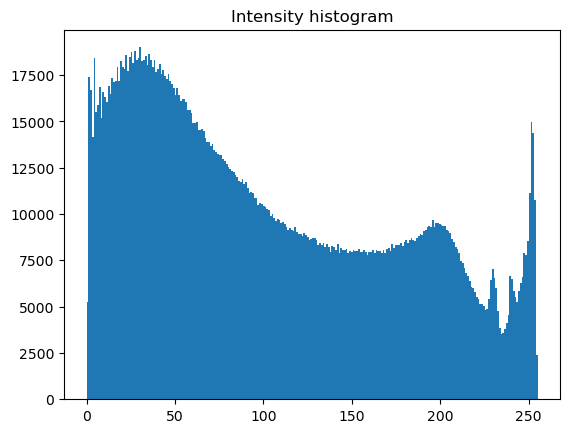

In [ ]:
# Intensity and channel histograms
if img is not None:
    plt.hist(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY).ravel(), bins=256)
    plt.title('Intensity histogram')
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

### Histogram-based Image Processing
Histogram-based image processing uses the distribution of pixel intensities to analyze and enhance images. By examining the histogram, we can adjust brightness, contrast, and exposure, detect features, and segment regions. This approach is essential because it provides a quantitative way to understand image quality and apply targeted corrections, making images more useful for visualization and further analysis.

**CLAHE (Contrast Limited Adaptive Histogram Equalization)** is an advanced method for improving image contrast, especially in images with varying lighting or local features. Unlike standard histogram equalization, which adjusts contrast globally, CLAHE works on small regions (tiles) of the image and limits amplification to avoid noise.

#### Standard Histogram Equalization
- **Global adjustment:** Redistributes pixel intensities across the entire image.
- **Best for:** Images with uniform lighting and global low contrast.
- **Drawbacks:** Can over-amplify noise and create unnatural effects in areas with little variation.

#### CLAHE
- **Local adjustment:** Applies histogram equalization to small tiles, then combines them.
- **Contrast limiting:** Prevents over-amplification of noise by clipping the histogram.
- **Best for:** Medical images, uneven lighting, or images with both bright and dark regions.
- **Advantages:** Preserves local details, avoids noise amplification, and produces more natural results.

**Summary:**  
Use standard histogram equalization for quick global contrast enhancement. Use CLAHE for images with local contrast issues, uneven illumination, or when you want to avoid boosting noise.

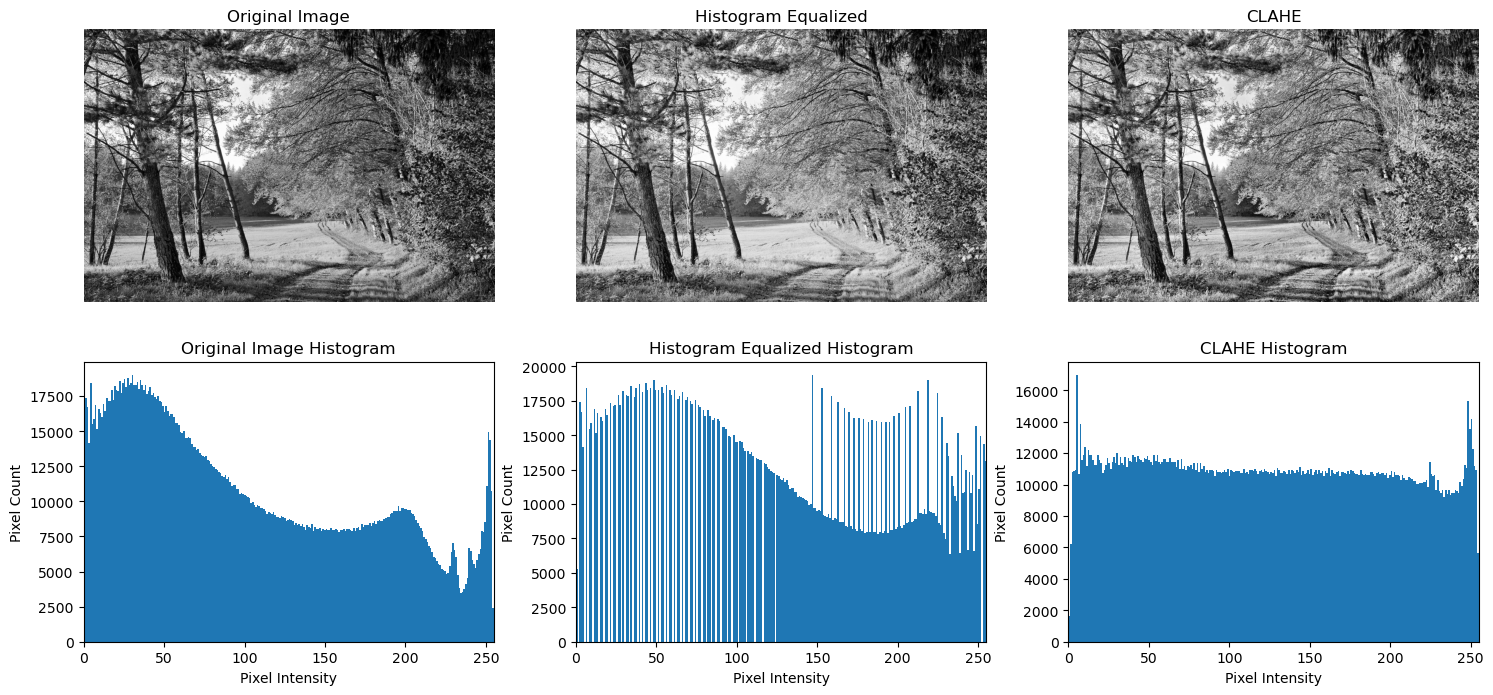

In [ ]:
# Histogram equalization and CLAHE comparison (grayscale, LAB luminance)
if img is not None:
    # Prepare processed images
    gray_eq = cv2.equalizeHist(gray)
    gray_clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    img_clahe = gray_clahe.apply(gray)

    # Figure 1: Images (2 rows x 3 cols)
    plt.figure(figsize=(18, 8))
    plt.subplot(2, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Image')
    plt.axis('off')
    plt.subplot(2, 3, 2)
    plt.imshow(gray_eq, cmap='gray')
    plt.title('Histogram Equalized')
    plt.axis('off')
    plt.subplot(2, 3, 3)
    plt.imshow(img_clahe, cmap='gray')
    plt.title('CLAHE')
    plt.axis('off')

    plt.subplot(2, 3, 4)
    plt.hist(gray.ravel(), bins=256)
    plt.title('Original Image Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Pixel Count')
    plt.xlim((0,255))
    plt.subplot(2, 3, 5)
    plt.hist(gray_eq.ravel(), bins=256)
    plt.title('Histogram Equalized Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Pixel Count')
    plt.xlim((0,255))
    plt.subplot(2, 3, 6)
    plt.hist(img_clahe.ravel(), bins=256)
    plt.title('CLAHE Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Pixel Count')
    plt.xlim((0,255))
else:
    print('Image not loaded. Run the first cell.')

## Binarization

**Binarization** is the process of converting a grayscale image into a binary image, where each pixel is either black (0) or white (255). This is done by applying a threshold: pixels above the threshold become white, and those below become black.

### Why Use Binarization?
- **Simplifies analysis:** Many image processing tasks (like shape analysis, object counting, and OCR) work better on binary images.
- **Separates foreground from background:** Useful for segmenting objects from their surroundings.
- **Preprocessing for algorithms:** Many algorithms (e.g., contour detection, morphological operations) require binary input.

### How Does Binarization Work?
1. **Choose a threshold value** (e.g., 100).
2. **Compare each pixel’s intensity** to the threshold.
    - If the pixel value > threshold, set it to 255 (white).
    - If the pixel value ≤ threshold, set it to 0 (black).

### Otsu’s Method — Automatic Threshold Selection

**Otsu’s method** is a popular technique for automatically finding the optimal threshold value. It works by:
- Analyzing the histogram of pixel intensities.
- Finding the threshold that minimizes the variance within each class (foreground and background), or equivalently, maximizes the separation between them.

**Advantages:**
- No manual tuning needed.
- Works well when the image has a clear bimodal histogram (two peaks: one for background, one for foreground).

**In practice:**  
Otsu’s method is widely used for document scanning, medical imaging, and any scenario where robust, automatic binarization is needed.

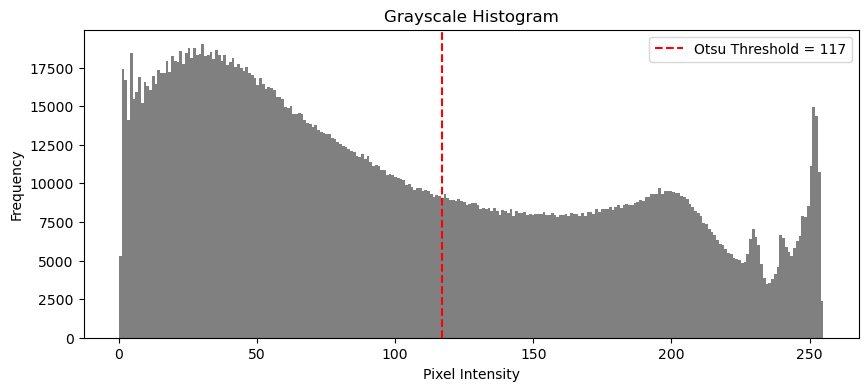

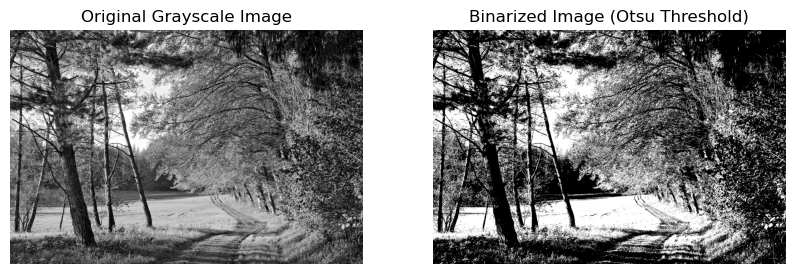

<Figure size 640x480 with 0 Axes>

In [ ]:
if img is not None:
    # Show histogram
    plt.figure(figsize=(10, 4))
    plt.hist(gray.ravel(), bins=256, color='gray')
    plt.title('Grayscale Histogram')
    plt.xlabel('Pixel Intensity')
    plt.ylabel('Frequency')
    # Otsu's thresholding
    otsu_thresh, binary_img = cv2.threshold(
        gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    plt.axvline(otsu_thresh, color='red', linestyle='dashed',
                label=f'Otsu Threshold = {otsu_thresh:.0f}')
    plt.legend()
    plt.show()

    plt.figure(figsize=(10,6))
    plt.subplot(1,2,1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale Image')
    plt.axis('off')
    # Show binarized image
    plt.subplot(1,2,2)
    plt.imshow(binary_img, cmap='gray')
    plt.title('Binarized Image (Otsu Threshold)')
    plt.axis('off')
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Smoothing / Blur — Purpose, Background, and Sharpening

Blurring (smoothing) is a fundamental image processing technique that reduces high-frequency noise and small details. It is commonly used before edge detection, thresholding, or segmentation to suppress speckle and minor artifacts, making features easier to analyze.

### Why Blur?
- **Noise reduction:** Removes random pixel fluctuations and small unwanted details.
- **Preprocessing:** Improves the reliability of subsequent steps like edge detection and binarization.
- **Visual effect:** Produces a softer, less detailed image.

A **Gaussian blur** uses a weighted kernel (must be odd-sized, e.g., 3x3, 5x5, 11x11) to average pixel values, giving more weight to the center. Larger kernels produce stronger smoothing.

### Sharpening

Sharpening enhances edges and fine details, making features stand out. It is often used after blurring or on its own to improve image clarity.

- **How it works:** Sharpening applies a kernel that emphasizes differences between neighboring pixels, boosting contrast at edges.
- **Common method:** The Laplacian or unsharp mask filter.

**Tip:**  
Use blurring to clean up noise before analysis. Use sharpening to highlight boundaries and details for visualization or feature extraction.

**Example kernels:**
- Gaussian blur:  
    ```
    [[1, 2, 1],
     [2, 4, 2],
     [1, 2, 1]] / 16
    ```
- Sharpening:  
    ```
    [[ 0, -1,  0],
     [-1,  5, -1],
     [ 0, -1,  0]]
    ```

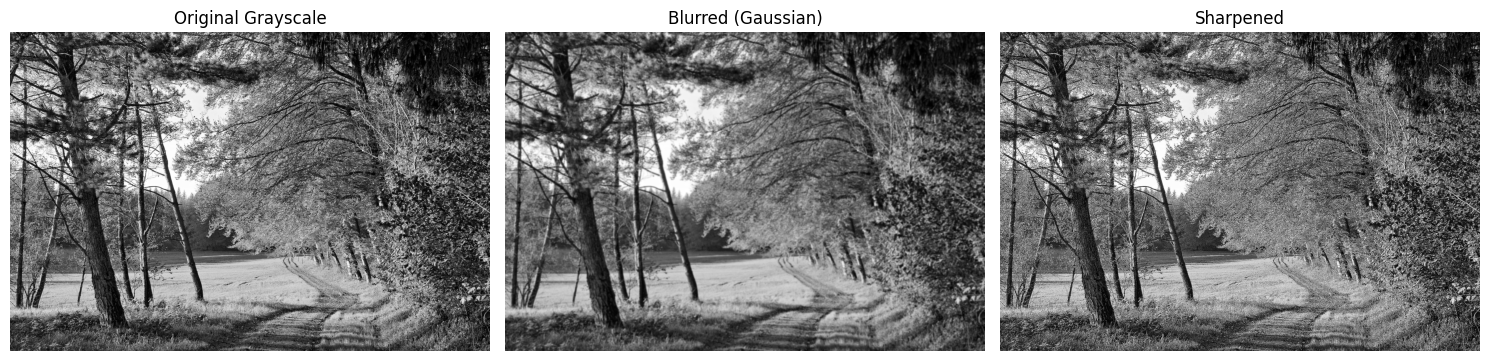

In [ ]:
if img is not None:
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(gray, cmap='gray')
    plt.title('Original Grayscale')
    plt.axis('off')

    # Gaussian blur with 11x11 kernel and sigma=0
    blurred = cv2.GaussianBlur(gray, (11, 11), 0)
    plt.subplot(1, 3, 2)
    plt.imshow(blurred, cmap='gray')
    plt.title('Blurred (Gaussian)')
    plt.axis('off')

    # Sharpening kernel
    sharpen_kernel = np.array([[0, -1, 0],
                               [-1, 5, -1],
                               [0, -1, 0]])
    sharpened = cv2.filter2D(gray, -1, sharpen_kernel)
    plt.subplot(1, 3, 3)
    plt.imshow(sharpened, cmap='gray')
    plt.title('Sharpened')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Morphological Operations

**Morphological operations** are image processing techniques that probe and modify the shapes of objects in binary or grayscale images. The two most common operations are **erosion** and **dilation**.

### What is Erosion?
- **Purpose:** Erosion shrinks bright regions and removes small white noise. It is useful for eliminating tiny artifacts, separating objects that are close together, and reducing the size of foreground objects.
- **How it works:** Erosion slides a small shape (called a *structuring element* or *kernel*) over the image. At each position, if *all* pixels under the kernel are bright (e.g., white in binary images), the output pixel remains bright; otherwise, it becomes dark. This causes boundaries of bright regions to shrink.

### What is Dilation?
- **Purpose:** Dilation expands bright regions and fills small holes or gaps. It is useful for joining broken parts of objects, making features thicker, and connecting nearby objects.
- **How it works:** Dilation also slides a kernel over the image. At each position, if *any* pixel under the kernel is bright, the output pixel becomes bright. This causes boundaries of bright regions to grow outward.

### Practical Use
- **Noise removal:** Erosion followed by dilation (called *opening*) removes small noise while preserving object shape.
- **Object joining:** Dilation followed by erosion (called *closing*) fills small holes and connects nearby objects.
- **Parameter tuning:** The size and shape of the kernel control the strength and direction of the effect. Larger kernels produce stronger changes.

**Tip:** Try different kernel sizes and shapes to see how they affect your image. Use erosion to clean up noise, and dilation to restore or connect features.

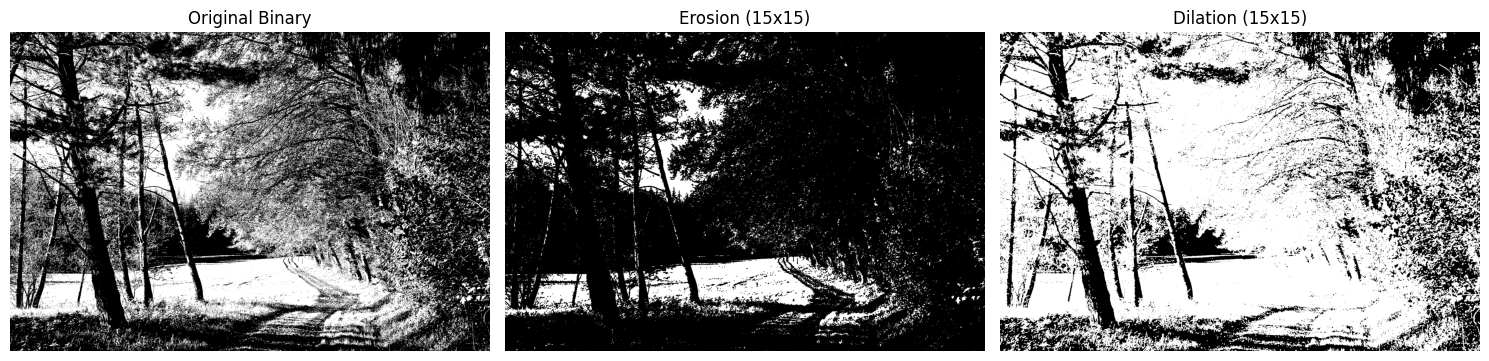

In [ ]:
# Erosion and dilation on binarized image
if img is not None:
    plt.figure(figsize=(15, 4))
    plt.subplot(1, 3, 1)
    plt.imshow(binary_img, cmap='gray')
    plt.title('Original Binary')
    plt.axis('off')

    # 15x15 kernel for demo. Adjust size as needed.
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (3, 3))

    eroded_bin = cv2.erode(binary_img, kernel, iterations=1)
    dilated_bin = cv2.dilate(binary_img, kernel, iterations=1)

    plt.subplot(1, 3, 2)
    plt.imshow(eroded_bin, cmap='gray')
    plt.title('Erosion (15x15)')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(dilated_bin, cmap='gray')
    plt.title('Dilation (15x15)')
    plt.axis('off')

    plt.tight_layout()
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Edge Detection

Edge detection is a fundamental technique in image processing and computer vision. **Edges** represent boundaries where pixel intensities change sharply, often corresponding to object outlines, texture changes, or surface discontinuities.

### Why Detect Edges?
- **Object boundaries:** Edges help segment objects from the background.
- **Feature extraction:** Many algorithms use edges to identify shapes, corners, and regions of interest.
- **Image understanding:** Edges simplify images, making it easier to analyze and interpret content.

### How Does Edge Detection Work?
Edge detectors analyze local intensity changes in an image. They highlight pixels where the difference between neighboring values is large. Common approaches include:
- **Gradient-based methods:** Compute the rate of change (gradient) in intensity. Examples: Sobel, Prewitt, Roberts.
- **Canny edge detector:** A multi-stage algorithm that smooths the image, finds gradients, applies non-maximum suppression, and uses double thresholding to select strong and weak edges.

### Canny Edge Detector
The Canny method is popular because it produces clean, thin edges and reduces noise. It uses two thresholds:
- **Low threshold:** Detects weak edges.
- **High threshold:** Detects strong edges.
Edges connected to strong edges are kept; isolated weak edges are discarded.

**Tip:** Adjust thresholds to control edge sensitivity. Lower values reveal more edges (including noise); higher values show only the most prominent boundaries.

Edge detection is a key step for tasks like segmentation, tracking, and recognition.

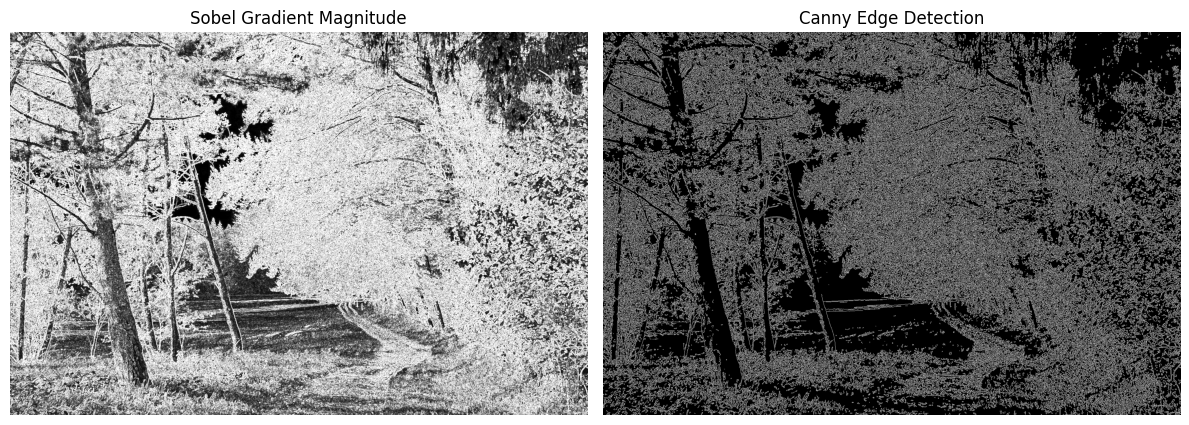

In [ ]:
# Compare Sobel gradient (simpler) with Canny edge detection (more complex)
if img is not None:
    # Sobel gradient (X and Y)
    sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
    sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
    sobel_mag = cv2.magnitude(sobelx, sobely)
    sobel_mag = cv2.convertScaleAbs(sobel_mag)

    # Canny edge detection
    edges_canny = cv2.Canny(gray, 200, 400)

    plt.figure(figsize=(12, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(sobel_mag, cmap='gray')
    plt.title('Sobel Gradient Magnitude')
    plt.axis('off')
    plt.subplot(1, 2, 2)
    plt.imshow(edges_canny, cmap='gray')
    plt.title('Canny Edge Detection')
    plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print('Image not loaded. Run the first cell.')

## Next Steps
Now that you've learned the basics of image representation, transformations, filtering, and detection techniques, you can explore more advanced topics. The following modules focus on medical imaging and processing techniques specific to that domain, building on the foundational skills you've acquired here.